# Experiment 4 — Benchmark Analysis

Reads `results_exp4.csv` (long format, one row per (dataset, method, seed)) and produces the figures
and tables for the benchmark write-up. The CSV schema is:
`dataset, d, n, seed, method, train_acc, train_f1, train_auc, test_acc, test_f1, test_auc, fit_time_s, timestamp`

Methods we expect (filtered case-by-case to whatever the CSV actually contains):
linear_svm, grad_boost, shallow_rff, mlp, rbf_exact, arch_proposed, and any additional baselines you ran
(wiering_mlsvm, acero_mlsvm).

The notebook does:
1. Per-dataset summary table (rows = datasets, columns = methods, cells = mean ± std test metric)
2. Critical-difference / pairwise ranking diagnostic
3. Per-dataset bar chart of methods at largest n
4. Headline metric chosen per dataset by imbalance


In [3]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from pathlib import Path

CSV = "../results_exp4.csv"

# preferred display order for methods that show up in the CSV
METHOD_ORDER = ["linear_svm","shallow_rff","rbf_exact","mlp","grad_boost",
                "wiering_mlsvm","acero_mlsvm","arch_proposed"]
METHOD_NICE = {
    "linear_svm":     "Linear SVM",
    "shallow_rff":    "Shallow RFF",
    "rbf_exact":      "Exact RBF",
    "mlp":            "MLP (3x200)",
    "grad_boost":     "Grad. Boosting",
    "wiering_mlsvm":  "Wiering & Schomaker",
    "acero_mlsvm":    "MLSVM (cosine RFF)",
    "arch_proposed":  "Proposed",
}

df = pd.read_csv(CSV)
# the runner writes "-" for failed cells; coerce to NaN so we can aggregate
num_cols = ["train_acc","train_f1","train_auc","test_acc","test_f1","test_auc","fit_time_s"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c].replace("-", np.nan), errors="coerce")
print("rows:", len(df), "| datasets:", sorted(df.dataset.unique()))
print("methods present:", sorted(df.method.unique()))
df.head(3)

rows: 180 | datasets: ['breast_cancer', 'covertype', 'ecoli', 'electricity', 'glass', 'ionosphere', 'letter', 'madelon', 'magic', 'spambase']
methods present: ['arch_proposed', 'grad_boost', 'linear_svm', 'mlp', 'rbf_exact', 'shallow_rff']


,dataset,d,n,seed,method,train_acc,train_f1,train_auc,test_acc,test_f1,test_auc,fit_time_s,timestamp
0,magic,10,15216,0,linear_svm,0.7909,0.7562,0.8401,0.7842,0.7471,0.8395,0.019,2026-06-24T04:30:27.140698
1,magic,10,15216,0,grad_boost,0.9157,0.9046,0.9688,0.8835,0.8680,0.9395,0.170,2026-06-24T04:30:27.378817
2,magic,10,15216,0,shallow_rff,0.8691,0.8502,0.9147,0.8715,0.8529,0.9207,0.680,2026-06-24T04:30:28.877786


## 1. Pick the headline metric per dataset

Following the protocol from Exp 3: on datasets where the strongest baseline shows a large
accuracy--macro-F1 divergence we use macro-F1 (imbalance signal); otherwise accuracy.

In [4]:
def headline_for(sub):
    # use the strongest non-trivial baseline (grad_boost if present, else mlp, else linear)
    for m in ["grad_boost","mlp","linear_svm"]:
        s = sub[sub.method==m]
        if len(s):
            acc = s.test_acc.mean(); f1 = s.test_f1.mean()
            if not (np.isnan(acc) or np.isnan(f1)) and acc - f1 > 0.25:
                return "test_f1", f"imbalanced (acc-F1 divergence {acc-f1:.2f} on {m})"
            break
    return "test_acc", "balanced"

meta = {}
for ds in sorted(df.dataset.unique()):
    sub = df[df.dataset==ds]
    metric, reason = headline_for(sub)
    meta[ds] = dict(metric=metric, reason=reason)
    print(f"{ds:14s} -> headline = {metric:8s}  ({reason})")

breast_cancer  -> headline = test_acc  (balanced)
covertype      -> headline = test_acc  (balanced)
ecoli          -> headline = test_acc  (balanced)
electricity    -> headline = test_acc  (balanced)
glass          -> headline = test_f1   (imbalanced (acc-F1 divergence 0.27 on grad_boost))
ionosphere     -> headline = test_acc  (balanced)
letter         -> headline = test_acc  (balanced)
madelon        -> headline = test_acc  (balanced)
magic          -> headline = test_acc  (balanced)
spambase       -> headline = test_acc  (balanced)


## 2. Summary table: methods x datasets (mean ± std)

One row per dataset, one column per method, cell shows mean ± std of the headline metric over seeds.
Bolds the winning method per dataset (best mean). Numbers are %, not fractions, since you're using
relative metrics elsewhere in the thesis.

In [5]:
def fmt_cell(mean, std, is_best):
    if np.isnan(mean): return "--"
    s = f"{100*mean:5.2f}"
    if not np.isnan(std) and std > 0:
        s += f" ± {100*std:4.2f}"
    return f"\\textbf{{{s}}}" if is_best else s

methods_present = [m for m in METHOD_ORDER if m in df.method.unique()]
table_rows = []
for ds in sorted(df.dataset.unique()):
    metric = meta[ds]["metric"]
    sub = df[df.dataset==ds]
    means = {}; stds = {}
    for m in methods_present:
        s = sub[sub.method==m][metric]
        means[m] = s.mean(); stds[m] = s.std(ddof=0) if len(s)>1 else 0.0
    valid = [m for m in methods_present if not np.isnan(means[m])]
    best = max(valid, key=lambda m: means[m]) if valid else None
    row = {"Dataset": ds, "metric": metric.replace("test_","")}
    for m in methods_present:
        row[METHOD_NICE.get(m,m)] = fmt_cell(means[m], stds[m], m==best)
    table_rows.append(row)
table_df = pd.DataFrame(table_rows)
print(table_df.to_string(index=False))

# LaTeX export (no auto-formatting beyond what's already in cells)
def to_latex(tdf, fname):
    cols = list(tdf.columns)
    out = "\\begin{tabular}{l" + "c"*(len(cols)-1) + "}\n\\toprule\n"
    out += " & ".join(cols) + " \\\\\n\\midrule\n"
    for _,r in tdf.iterrows():
        out += " & ".join(str(r[c]) for c in cols) + " \\\\\n"
    out += "\\bottomrule\n\\end{tabular}\n"
    open(fname,"w").write(out); print(f"saved {fname}")
to_latex(table_df, "exp4_summary_table.tex")
table_df.to_csv("exp4_summary_table.csv", index=False)

      Dataset metric            Linear SVM  Shallow RFF             Exact RBF           MLP (3x200)        Grad. Boosting              Proposed
breast_cancer    acc          94.83 ± 0.94 94.67 ± 0.24          94.17 ± 0.62          95.17 ± 0.47          95.33 ± 0.47 \textbf{95.67 ± 0.24}
    covertype    acc          71.32 ± 0.30 72.91 ± 0.36                    -- \textbf{91.39 ± 0.57}          85.13 ± 2.41          76.09 ± 0.38
        ecoli    acc          89.58 ± 0.12 85.75 ± 0.61          96.50 ± 1.43          94.92 ± 1.33 \textbf{96.92 ± 0.42}          82.42 ± 1.70
  electricity    acc          75.89 ± 0.32 78.71 ± 0.25          80.82 ± 0.17          84.42 ± 0.41 \textbf{90.29 ± 0.21}          81.42 ± 0.25
        glass     f1 \textbf{43.27 ± 7.32} 29.24 ± 2.55          39.28 ± 5.97          31.33 ± 4.39                  8.73                  8.73
   ionosphere    acc          86.00 ± 1.08 92.33 ± 2.78 \textbf{95.17 ± 0.85}          87.50 ± 1.08                 92.00          92.67

## 3. Per-dataset bar chart

Visual companion to the table: one bar group per dataset, one bar per method, error bars = ± std.

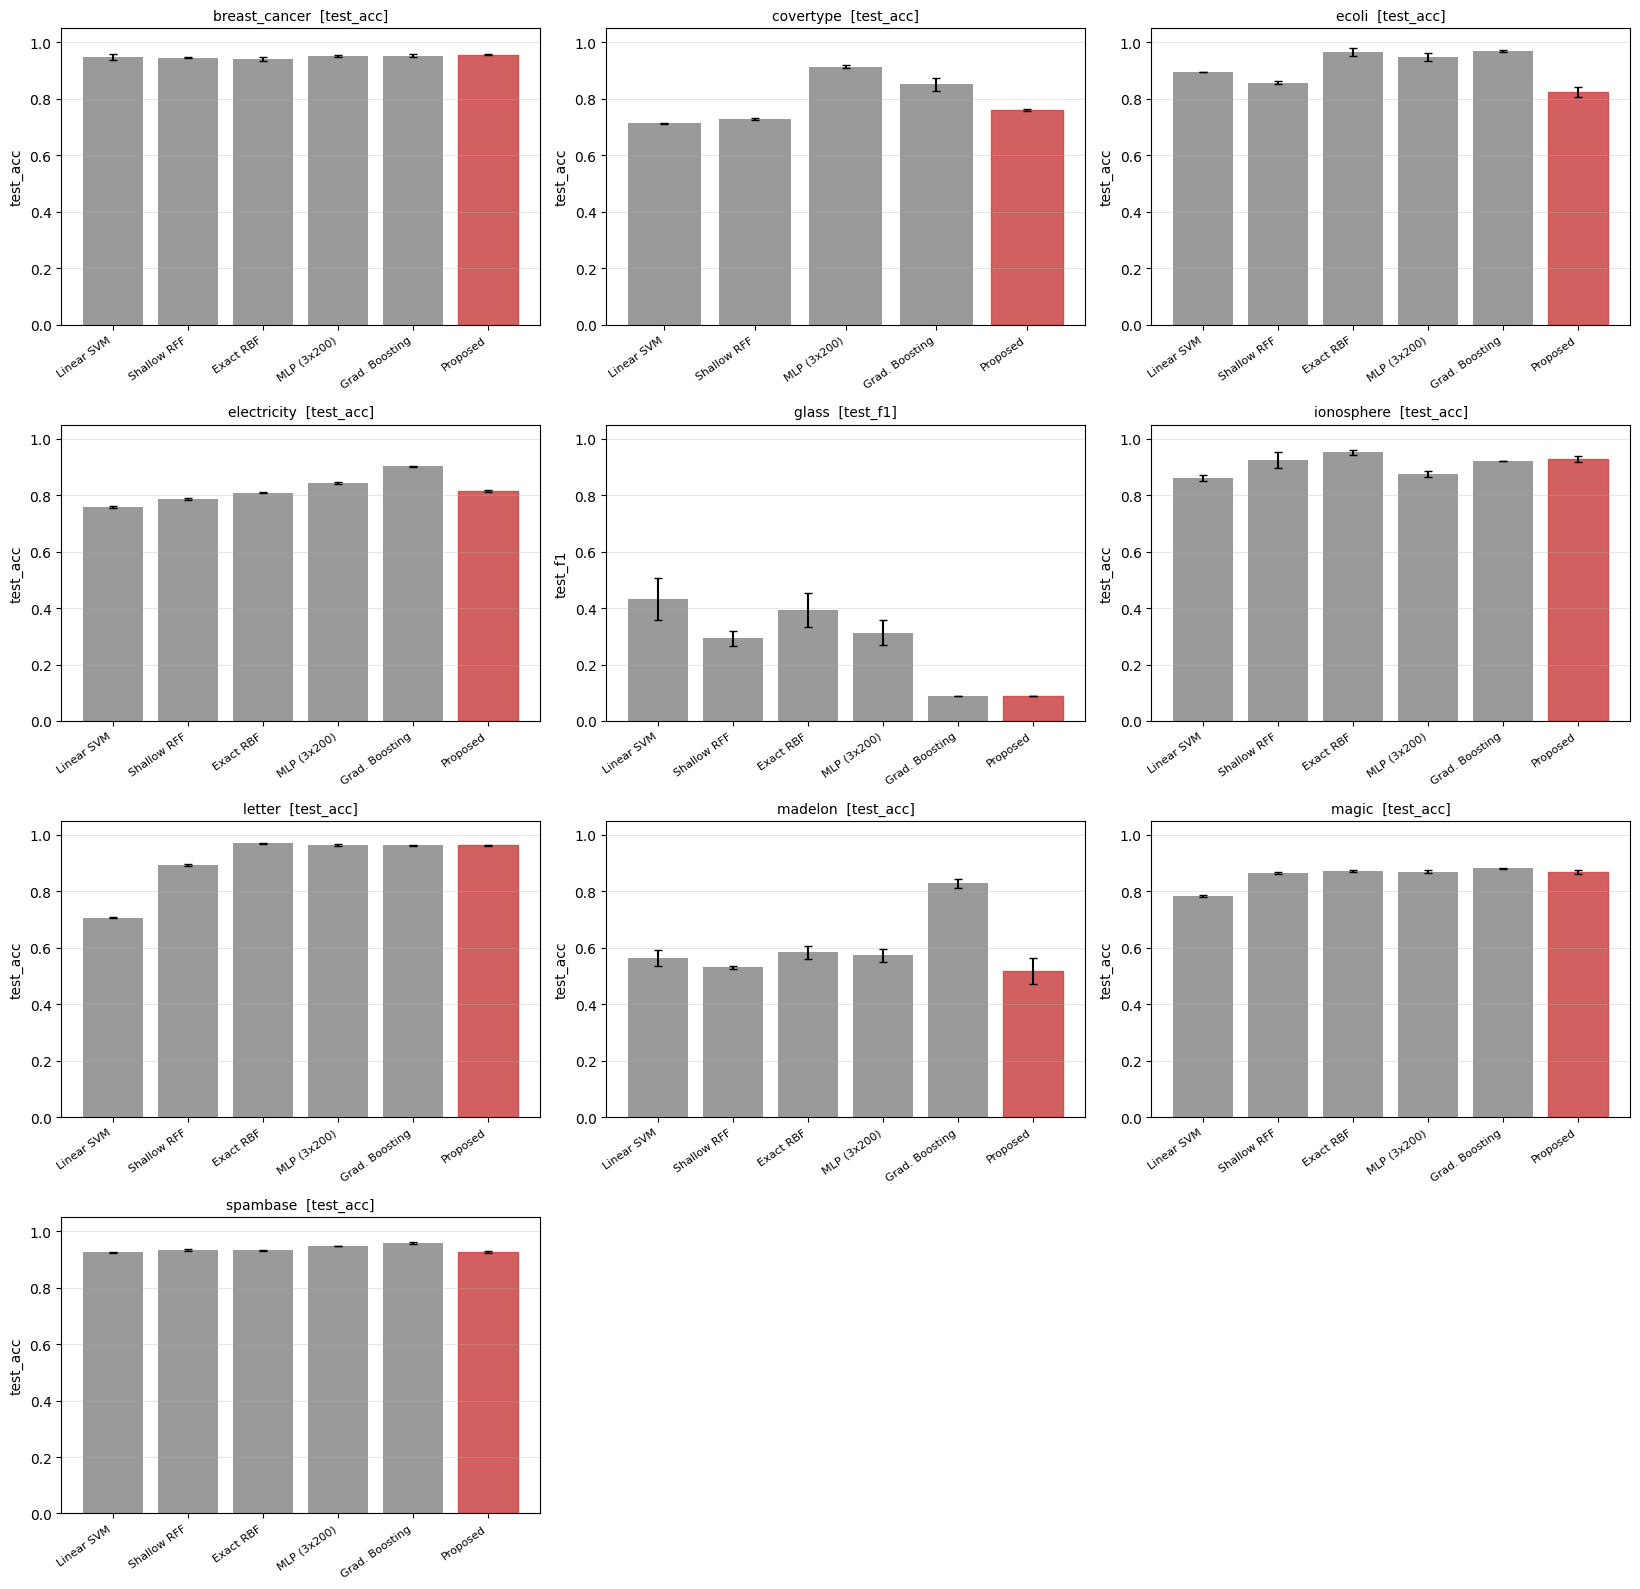

saved fig_exp4_bars.png


In [6]:
datasets = sorted(df.dataset.unique())
methods_present = [m for m in METHOD_ORDER if m in df.method.unique()]
ncol = 3; nrow = int(np.ceil(len(datasets)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5.5*ncol, 4*nrow), squeeze=False)
axes = axes.ravel()

for i, ds in enumerate(datasets):
    ax = axes[i]; metric = meta[ds]["metric"]
    sub = df[df.dataset==ds]
    means, stds, labels = [], [], []
    for m in methods_present:
        s = sub[sub.method==m][metric]
        if len(s) == 0 or s.isna().all(): continue
        means.append(s.mean()); stds.append(s.std(ddof=0) if len(s)>1 else 0)
        labels.append(METHOD_NICE.get(m,m))
    x = np.arange(len(labels))
    bars = ax.bar(x, means, yerr=stds, capsize=3, alpha=.85,
                  color=["#888"]*(len(labels)-1) + ["#c44"])
    # highlight the proposed method in red
    for j, lab in enumerate(labels):
        if "Proposed" in lab: bars[j].set_color("#c44")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel(metric); ax.set_title(f"{ds}  [{metric}]", fontsize=10)
    ax.grid(axis="y", alpha=.3)
    ax.set_ylim(0, 1.05)

for j in range(len(datasets), len(axes)): axes[j].axis("off")
plt.tight_layout()
plt.savefig("fig_exp4_bars.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved fig_exp4_bars.png")

## 4. Average rank per method

Across datasets, what rank does each method achieve on its headline metric? Lower = better.
A robust summary that doesn't depend on absolute metric scales differing across datasets.

                mean rank   std  # datasets
Grad. Boosting       2.00  1.41          10
Exact RBF            2.67  1.66           9
MLP (3x200)          2.80  1.03          10
Proposed             4.00  1.76          10
Shallow RFF          4.40  0.84          10
Linear SVM           4.80  1.62          10


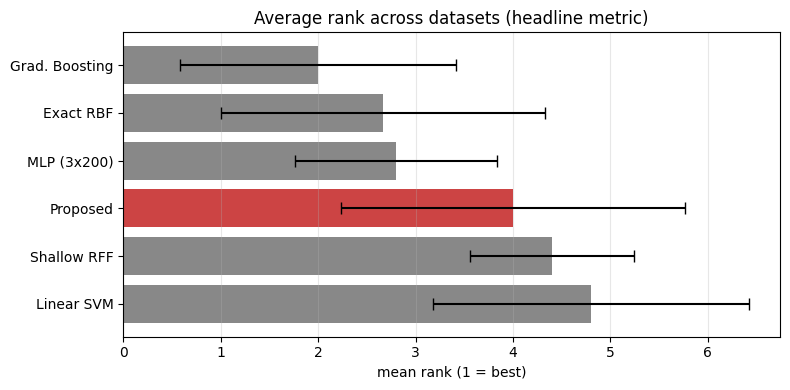

saved fig_exp4_ranks.png


In [7]:
ranks = []
for ds in datasets:
    metric = meta[ds]["metric"]
    sub = df[df.dataset==ds]
    means = {}
    for m in methods_present:
        s = sub[sub.method==m][metric]
        if len(s) and not s.isna().all(): means[m] = s.mean()
    if not means: continue
    # rank: 1 = best
    sorted_ms = sorted(means.items(), key=lambda kv: -kv[1])
    for rank, (m, _) in enumerate(sorted_ms, 1):
        ranks.append({"dataset":ds, "method":m, "rank":rank, "score":means[m]})
ranks_df = pd.DataFrame(ranks)

avg_rank = ranks_df.groupby("method")["rank"].agg(["mean","std","count"]).sort_values("mean")
avg_rank.index = [METHOD_NICE.get(m,m) for m in avg_rank.index]
avg_rank.columns = ["mean rank","std","# datasets"]
print(avg_rank.round(2).to_string())

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(avg_rank.index, avg_rank["mean rank"], xerr=avg_rank["std"], capsize=4,
        color=["#c44" if "Proposed" in n else "#888" for n in avg_rank.index])
ax.set_xlabel("mean rank (1 = best)"); ax.invert_yaxis()
ax.set_title("Average rank across datasets (headline metric)")
ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.savefig("fig_exp4_ranks.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved fig_exp4_ranks.png")

## 5. Wins / ties / losses against gradient boosting

Pairwise view focused on the toughest comparator. For each dataset, how does the proposed method
stand against grad. boosting in the headline metric? A tie is a difference smaller than 1 standard
deviation of the proposed method's seed variance — i.e. not statistically distinguishable.

In [8]:
rows = []
for ds in datasets:
    metric = meta[ds]["metric"]
    sub = df[df.dataset==ds]
    p = sub[sub.method=="arch_proposed"][metric]
    g = sub[sub.method=="grad_boost"][metric]
    if not len(p) or not len(g): continue
    p_mean, p_std = p.mean(), p.std(ddof=0) if len(p)>1 else 0
    g_mean = g.mean()
    diff = p_mean - g_mean
    if abs(diff) < max(p_std, 0.005):
        verdict = "tie"
    else:
        verdict = "win" if diff > 0 else "loss"
    rows.append({"dataset":ds, "metric":metric, "proposed":p_mean, "grad_boost":g_mean,
                 "diff":diff, "verdict":verdict})
vs_gb = pd.DataFrame(rows)
print(vs_gb.round(4).to_string(index=False))
print("\ntally:", vs_gb.verdict.value_counts().to_dict())

      dataset   metric  proposed  grad_boost    diff verdict
breast_cancer test_acc    0.9567      0.9533  0.0033     tie
    covertype test_acc    0.7609      0.8513 -0.0904    loss
        ecoli test_acc    0.8242      0.9692 -0.1450    loss
  electricity test_acc    0.8142      0.9029 -0.0887    loss
        glass  test_f1    0.0873      0.0873  0.0000     tie
   ionosphere test_acc    0.9267      0.9200  0.0067     tie
       letter test_acc    0.9627      0.9633 -0.0005     tie
      madelon test_acc    0.5173      0.8282 -0.3109    loss
        magic test_acc    0.8684      0.8812 -0.0129    loss
     spambase test_acc    0.9268      0.9594 -0.0326    loss

tally: {'loss': 6, 'tie': 4}


## 6. Sanity checks

These flag protocol issues we'd want to catch before writing up. Each block prints a warning if
something looks off and stays silent otherwise.

In [9]:
# (a) Did every method run on every dataset?
expected = set((ds,m) for ds in datasets for m in methods_present)
actual = set(zip(df.dataset, df.method))
missing = expected - actual
if missing:
    print("MISSING (dataset, method) pairs:")
    for ds,m in sorted(missing): print(f"  {ds:14s} {m}")
else:
    print("[OK] every method ran on every dataset")

# (b) Are seed counts consistent?
seeds = df.groupby(["dataset","method"]).seed.nunique()
odd = seeds[seeds != seeds.mode()[0]]
if len(odd):
    print("\nINCONSISTENT seed counts:")
    print(odd.to_string())
else:
    print("[OK] consistent seed count of", seeds.mode()[0])

# (c) Any method scoring at chance-level somewhere it shouldn't?
for ds in datasets:
    sub = df[df.dataset==ds]
    n_classes = 2  # placeholder; you can refine if you track this
    chance = 1.0/n_classes
    for m in methods_present:
        acc = sub[sub.method==m].test_acc.mean()
        if not np.isnan(acc) and acc < chance + 0.02 and m not in ("linear_svm",):
            print(f"  WARNING: {m} on {ds} at chance level ({acc:.3f})")

[OK] every method ran on every dataset
[OK] consistent seed count of 3
